In [1]:
################################################################################
# 0. SETUP AND IMPORTS
################################################################################


import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from collections import defaultdict, Counter
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from nltk.corpus import stopwords
from scipy.sparse import csr_matrix
# pip install umap-learn
from sklearn.preprocessing import normalize
import numpy as np
from collections import Counter

################################################################################
# 1. LOAD TEXT DATA
################################################################################

file_path = 'text8'

with open(file_path, 'r') as file:
    all_text = file.read()

print(f"Loaded text length: {len(all_text)} characters")

Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 2.9 MB/s eta 0:00:00
Loaded text length: 100000000 characters


In [2]:
################################################################################
# 2. SPLIT INTO TRAIN, VALIDATION, AND TEST SETS
################################################################################
#  - 80% = TrainVal
#  - 20% = Test
# Then from TrainVal:
#  - 80% of TrainVal = Train
#  - 20% of TrainVal = Val

tokens = nltk.word_tokenize(all_text.lower())
total_length = len(tokens)
test_ratio = 0.2
test_index = int(total_length * test_ratio)

# Step 1: Split Test set
trainval_tokens_raw = tokens[: (total_length - test_index)]
test_tokens_raw = tokens[(total_length - test_index):]


print("##############################################")
print("STEP 1: SPLIT TEST SET")
print(f"Total tokens: {total_length}")
print(f"Test set ratio: {test_ratio} ({test_ratio * 100:.2f}%)")
print(f"Test set tokens removed: {len(test_tokens_raw)}")
print(f"Remaining TrainVal tokens: {len(trainval_tokens_raw)} ({(1 - test_ratio) * 100:.2f}%)\n")

# Step 2: Split TrainVal into Train and Validation
val_ratio = 0.2
val_index = int(len(trainval_tokens_raw) * val_ratio)

train_tokens_raw = trainval_tokens_raw[: (len(trainval_tokens_raw) - val_index)]
val_tokens_raw = trainval_tokens_raw[(len(trainval_tokens_raw) - val_index):]

print("##############################################")
print("STEP 2: SPLIT TRAINVAL INTO TRAIN AND VALIDATION")
print(f"TrainVal tokens before split: {len(trainval_tokens_raw)}")
print(f"Validation set ratio: {val_ratio} ({val_ratio * 100:.2f}%)")
print(f"Validation set tokens removed: {len(val_tokens_raw)}")
print(f"Remaining Train tokens: {len(train_tokens_raw)} ({(1 - val_ratio) * 100:.2f}% of TrainVal)\n")

# Summary of splits
print("##############################################")
print("FINAL SPLIT SUMMARY:")
print(f"  Total tokens:       {total_length}")
print(f"  Test set:           {len(test_tokens_raw)} tokens ({100 * test_ratio:.2f}%)")
print(f"  TrainVal set:       {len(trainval_tokens_raw)} tokens ({100 * (1 - test_ratio):.2f}%)")
print(f"    Train set:        {len(train_tokens_raw)} tokens ({100 * (1 - test_ratio) * (1 - val_ratio):.2f}%)")
print(f"    Validation set:   {len(val_tokens_raw)} tokens ({100 * (1 - test_ratio) * val_ratio:.2f}%)")
print("##############################################\n")


##############################################
STEP 1: SPLIT TEST SET
Total tokens: 17007698
Test set ratio: 0.2 (20.00%)
Test set tokens removed: 3401539
Remaining TrainVal tokens: 13606159 (80.00%)

##############################################
STEP 2: SPLIT TRAINVAL INTO TRAIN AND VALIDATION
TrainVal tokens before split: 13606159
Validation set ratio: 0.2 (20.00%)
Validation set tokens removed: 2721231
Remaining Train tokens: 10884928 (80.00% of TrainVal)

##############################################
FINAL SPLIT SUMMARY:
  Total tokens:       17007698
  Test set:           3401539 tokens (20.00%)
  TrainVal set:       13606159 tokens (80.00%)
    Train set:        10884928 tokens (64.00%)
    Validation set:   2721231 tokens (16.00%)
##############################################



In [22]:
################################################################################
# 3. SYNONYM MAPPING AND PREPROCESSING FUNCTIONS (Improved)
################################################################################

import nltk
from collections import Counter
from nltk import pos_tag
from nltk.corpus import stopwords, words, wordnet
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download("stopwords")
nltk.download("words")
nltk.download("wordnet")
nltk.download('averaged_perceptron_tagger_eng')

# Define stopwords, number words, and additional parameters
custom_stopwords = set(stopwords.words("english"))
custom_stopwords.update([str(i) for i in range(100)])
custom_stopwords.update([
    "one", "two", "three", "four", "five", "six", "seven", "eight", "nine",
    "ten", "hundred", "thousand", "million", "billion", "trillion",
    "zero", "zero zero", "one zero zero zero"
])

english_words = set(words.words())
lemmatizer = WordNetLemmatizer()

MIN_WORD_LENGTH = 3
MAX_WORD_LENGTH = 18
LOWER_FREQ_THRESHOLD = 50
UPPER_FREQ_THRESHOLD = 5000


def get_wordnet_pos(treebank_tag):
    """
    Convert Treebank POS tags to WordNet POS tags.
    This ensures synonyms come from the correct part of speech.
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None


def get_synonyms_enhanced(word, pos_tag, corpus_vocabulary):
    """
    Fetch synonyms for 'word' filtered by part-of-speech and corpus membership.
      - Only synonyms matching the provided POS are returned.
      - Only synonyms that appear in corpus_vocabulary are kept.
      - Multi-word synonyms (with underscores) are excluded.
    """
    wn_pos = get_wordnet_pos(pos_tag)
    synonyms = set()

    if wn_pos:
        for synset in wordnet.synsets(word, wn_pos):
            for lemma in synset.lemmas():
                candidate = lemma.name().lower()
                if "_" not in candidate and candidate in corpus_vocabulary:
                    synonyms.add(candidate)
    return synonyms if synonyms else {word}


def preprocess_and_filter(raw_tokens):
    """
    Preprocess a list of tokens:
      1) Lowercase
      2) Filter out non-ASCII
      3) Retain only alphabetic words
      4) Retain valid English words
      5) Remove custom stopwords and numeric words
      6) Filter by length
      7) Lemmatize
    """
    initial_count = len(raw_tokens)

    # Step 1: Lowercase
    tokens = [t.lower() for t in raw_tokens]
    print(f"Step 1 (Lowercase): Removed {initial_count - len(tokens)} tokens")
    initial_count = len(tokens)

    # Step 2: Filter non-ASCII characters
    tokens = [t for t in tokens if t.isascii()]
    print(f"Step 2 (ASCII): Removed {initial_count - len(tokens)} tokens")
    initial_count = len(tokens)

    # Step 3: Retain alphabetic words only
    tokens = [t for t in tokens if t.isalpha()]
    print(f"Step 3 (Alpha): Removed {initial_count - len(tokens)} tokens")
    initial_count = len(tokens)

    # Step 5: Remove stopwords and number words
    tokens = [t for t in tokens if t not in custom_stopwords]
    print(f"Step 5 (Stopwords and Numbers): Removed {initial_count - len(tokens)} tokens")
    initial_count = len(tokens)

    # Step 6: Filter by length
    tokens = [t for t in tokens if MIN_WORD_LENGTH <= len(t) <= MAX_WORD_LENGTH]
    print(f"Step 6 (Length Check): Removed {initial_count - len(tokens)} tokens")
    initial_count = len(tokens)

    # Step 7: Apply lemmatization
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    print(f"Step 7 (Lemmatization): Total tokens remain the same")

    return lemmatized


def build_synonym_mapping(unique_tokens):
    """
    Build a synonym mapping dictionary from unique tokens using POS-specific lookups
    and restricting synonyms to those present in the corpus.
    """
    token_list = list(unique_tokens)
    tagged_tokens = pos_tag(token_list)

    corpus_vocabulary = set(unique_tokens)

    synonym_mapping = {}
    for token, tb_tag in tagged_tokens:
        synonyms = get_synonyms_enhanced(token, tb_tag, corpus_vocabulary)
        primary_synonym = min(synonyms)
        synonym_mapping[token] = primary_synonym

    return synonym_mapping


def apply_synonym_mapping(tokens, synonym_mapping):
    """
    Replace words in tokens with their primary synonym based on synonym_mapping.
    Logs how many mappings were applied and shows examples.
    """
    mapped_count = 0

    mapped_tokens = []
    for token in tokens:
        if token in synonym_mapping:
            mapped_count += 1
            mapped_token = synonym_mapping[token]
            mapped_tokens.append(mapped_token)
        else:
            mapped_tokens.append(token)

    # Log results
    print(f"\nTotal synonym mappings applied: {mapped_count}")

    return mapped_tokens


def filter_by_frequency(tokens, lower_threshold, upper_threshold):
    """
    Filter tokens by frequency within specified bounds and log details.
    Returns (filtered_tokens, filtered_vocab).
    """
    word_freq = Counter(tokens)
    print(f"\nInitial unique tokens: {len(word_freq)}")

    # Count words below and above the thresholds
    below_threshold_count = sum(1 for freq in word_freq.values() if freq < lower_threshold)
    above_threshold_count = sum(1 for freq in word_freq.values() if freq > upper_threshold)

    print(f"Words with occurrences below {lower_threshold}: {below_threshold_count}")
    print(f"Words with occurrences above {upper_threshold}: {above_threshold_count}")

    # Retain words within the thresholds
    filtered_vocab = {
        word for word, freq in word_freq.items()
        if lower_threshold <= freq <= upper_threshold
    }
    print(f"Words retained between {lower_threshold} and {upper_threshold} occurrences: {len(filtered_vocab)}")

    # Filter tokens based on the filtered vocabulary
    filtered_tokens = [word for word in tokens if word in filtered_vocab]

    return filtered_tokens, filtered_vocab


################################################################################
# 4. PREPROCESS TRAIN, VAL, AND TEST TOKENS WITH SYNONYM MAPPING
################################################################################

# 1. Preprocess Train set
print("\nPreprocessing Train tokens...")
train_tokens_filtered = preprocess_and_filter(train_tokens_raw)

# 2. Build Synonym Mapping (POS-specific, corpus-based)
print("\nBuilding synonym mapping...")
unique_tokens = set(train_tokens_filtered)
synonym_mapping = build_synonym_mapping(unique_tokens)

# 3. Apply Synonym Mapping
print("\nApplying synonym mapping to Train tokens...")
train_tokens_mapped = apply_synonym_mapping(train_tokens_filtered, synonym_mapping)

# 4. Frequency Filtering
print("\nFiltering Train tokens by frequency...")
train_tokens_filtered, train_vocab_filtered = filter_by_frequency(
    train_tokens_mapped, LOWER_FREQ_THRESHOLD, UPPER_FREQ_THRESHOLD
)

# 5. Log final results
print(f"\nFinal Train tokens after frequency filtering: {len(train_tokens_filtered)}")
print(f"Final unique Train words after frequency filtering: {len(train_vocab_filtered)}")

print("\nPreprocessing Validation tokens...")
val_tokens_filtered = preprocess_and_filter(val_tokens_raw)

print("\nApplying synonym mapping to Validation tokens...")
val_tokens_mapped = apply_synonym_mapping(val_tokens_filtered, synonym_mapping)

print("\nFiltering Validation tokens by frequency...")
val_tokens_filtered, val_vocab_filtered = filter_by_frequency(
    val_tokens_mapped, LOWER_FREQ_THRESHOLD, UPPER_FREQ_THRESHOLD
)

# Log final validation results
print(f"\nFinal Validation tokens after frequency filtering: {len(val_tokens_filtered)}")
print(f"Final unique Validation words after frequency filtering: {len(val_vocab_filtered)}")

# Preprocess Test set
print("\nPreprocessing Test tokens...")
test_tokens_filtered = preprocess_and_filter(test_tokens_raw)

print("\nApplying synonym mapping to Test tokens...")
test_tokens_mapped = apply_synonym_mapping(test_tokens_filtered, synonym_mapping)

print("\nFiltering Test tokens by frequency...")
test_tokens_filtered, test_vocab_filtered = filter_by_frequency(
    test_tokens_mapped, LOWER_FREQ_THRESHOLD, UPPER_FREQ_THRESHOLD
)

# Log final Test results
print(f"\nFinal Test tokens after frequency filtering: {len(test_tokens_filtered)}")
print(f"Final unique Test words after frequency filtering: {len(test_vocab_filtered)}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!



Preprocessing Train tokens...
Step 1 (Lowercase): Removed 0 tokens
Step 2 (ASCII): Removed 0 tokens
Step 3 (Alpha): Removed 0 tokens
Step 5 (Stopwords and Numbers): Removed 5041546 tokens
Step 6 (Length Check): Removed 175720 tokens
Step 7 (Lemmatization): Total tokens remain the same

Building synonym mapping...

Applying synonym mapping to Train tokens...

Total synonym mappings applied: 5667662

Filtering Train tokens by frequency...

Initial unique tokens: 166599
Words with occurrences below 50: 157178
Words with occurrences above 5000: 156
Words retained between 50 and 5000 occurrences: 9265

Final Train tokens after frequency filtering: 3605792
Final unique Train words after frequency filtering: 9265

Preprocessing Validation tokens...
Step 1 (Lowercase): Removed 0 tokens
Step 2 (ASCII): Removed 0 tokens
Step 3 (Alpha): Removed 0 tokens
Step 5 (Stopwords and Numbers): Removed 1290944 tokens
Step 6 (Length Check): Removed 43473 tokens
Step 7 (Lemmatization): Total tokens remain t

In [23]:
################################################################################
# Enhanced Normalization and Co-Occurrence Matrix Function
################################################################################

from collections import Counter
import numpy as np
from scipy.sparse import lil_matrix, csr_matrix
from sklearn.preprocessing import normalize

def build_normalized_co_occurrence(tokens, vocab, window_size=2, min_freq=5):
    word_index = {word: idx for idx, word in enumerate(vocab)}

    # Initialize sparse co-occurrence matrix
    co_occ = lil_matrix((len(vocab), len(vocab)), dtype=float)

    # Build co-occurrence matrix without weighting
    for i, word in enumerate(tokens):
        if word not in word_index:
            continue
        w_idx = word_index[word]
        for j in range(1, window_size + 1):
            # Forward co-occurrence
            if i + j < len(tokens) and tokens[i + j] in word_index:
                co_occ[w_idx, word_index[tokens[i + j]]] += 1
            # Backward co-occurrence
            if i - j >= 0 and tokens[i - j] in word_index:
                co_occ[w_idx, word_index[tokens[i - j]]] += 1

    # Convert to CSR format for efficient normalization
    co_occ = co_occ.tocsr()

    # Apply L2 normalization row-wise
    return normalize(co_occ, norm='l2', axis=1)

def normalize_frequencies(tokens_filtered, min_freq=5):
    word_freq = Counter(tokens_filtered)
    vocab = [word for word, freq in word_freq.items() if freq >= min_freq]
    return vocab

################################################################################
# 5. BUILD TRAIN VOCAB AND CO-OCCURRENCE MATRICES
################################################################################

# Build vocabulary from train tokens
train_vocab = normalize_frequencies(train_tokens_filtered, min_freq=5)
print(f"Train Vocabulary Size: {len(train_vocab)}")

# Build co-occurrence matrix for train set
print("Building and normalizing the train co-occurrence matrix...")
train_co_matrix_normalized = build_normalized_co_occurrence(
    train_tokens_filtered,
    train_vocab,
    window_size=5,
    min_freq=5
)
print(f"Train Co-Occurrence Matrix Shape: {train_co_matrix_normalized.shape}")

# Build co-occurrence matrix for validation set (using train vocabulary)
print("Building and normalizing the validation co-occurrence matrix...")
val_co_matrix_normalized = build_normalized_co_occurrence(
    val_tokens_filtered,
    train_vocab,
    window_size=5,
    min_freq=5
)
print(f"Validation Co-Occurrence Matrix Shape: {val_co_matrix_normalized.shape}")


Train Vocabulary Size: 9265
Building and normalizing the train co-occurrence matrix...
Train Co-Occurrence Matrix Shape: (9265, 9265)
Building and normalizing the validation co-occurrence matrix...
Validation Co-Occurrence Matrix Shape: (9265, 9265)


In [27]:
################################################################################
# TRAINING WITH CHOSEN HYPERPARAMETERS
################################################################################

from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


k_range = range(2, 20)


print("Applying PCA with 20 components...")
pca_model = PCA(n_components=20, random_state=42)
train_pca_reduced = pca_model.fit_transform(train_co_matrix_normalized)
val_pca_reduced   = pca_model.transform(val_co_matrix_normalized)


print("Applying UMAP (n_components=5, n_neighbors=10, min_dist=0.1)...")
umap_model = UMAP(
    n_components=5,
    n_neighbors=10,
    min_dist=0.1,
)
train_umap_reduced = umap_model.fit_transform(train_pca_reduced)
val_umap_reduced   = umap_model.transform(val_pca_reduced)

silhouette_scores = []
inertias = []

print("\nEvaluating different k on the Validation set...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    train_labels = kmeans.fit_predict(train_umap_reduced)

    inertia = kmeans.inertia_

    # Predict clusters for the VALIDATION data
    val_labels = kmeans.predict(val_umap_reduced)

    # Compute silhouette on the validation embedding
    if k > 1:
        sil_score = silhouette_score(val_umap_reduced, val_labels)
    else:
        sil_score = -1

    silhouette_scores.append(sil_score)
    inertias.append(inertia)

    print(f"  k={k}  |  Train Inertia={inertia:.3f},  Val Silhouette={sil_score:.3f}")

valid_k_scores = [(k, score) for k, score in zip(k_range, silhouette_scores) if k < 8]

# Identify the best k based on the maximum silhouette score
best_k, best_score = max(valid_k_scores, key=lambda x: x[1])

print(f"\nBest k by Validation Silhouette (k < 8) = {best_k} with a silhouette score of {best_score:.3f}\n")


Applying PCA with 20 components...
Applying UMAP (n_components=5, n_neighbors=10, min_dist=0.1)...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Evaluating different k on the Validation set...
  k=2  |  Train Inertia=50313.508,  Val Silhouette=0.596
  k=3  |  Train Inertia=40213.301,  Val Silhouette=0.611
  k=4  |  Train Inertia=33751.602,  Val Silhouette=0.632
  k=5  |  Train Inertia=29646.887,  Val Silhouette=0.653
  k=6  |  Train Inertia=25722.094,  Val Silhouette=0.661
  k=7  |  Train Inertia=23330.656,  Val Silhouette=0.698
  k=8  |  Train Inertia=22698.490,  Val Silhouette=0.677
  k=9  |  Train Inertia=20081.736,  Val Silhouette=0.685
  k=10  |  Train Inertia=18002.928,  Val Silhouette=0.694
  k=11  |  Train Inertia=16407.688,  Val Silhouette=0.729
  k=12  |  Train Inertia=15564.793,  Val Silhouette=0.717
  k=13  |  Train Inertia=14582.490,  Val Silhouette=0.719
  k=14  |  Train Inertia=13186.301,  Val Silhouette=0.721
  k=15  |  Train Inertia=12589.867,  Val Silhouette=0.721
  k=16  |  Train Inertia=12187.713,  Val Silhouette=0.722
  k=17  |  Train Inertia=11079.652,  Val Silhouette=0.715
  k=18  |  Train Inertia=10338.

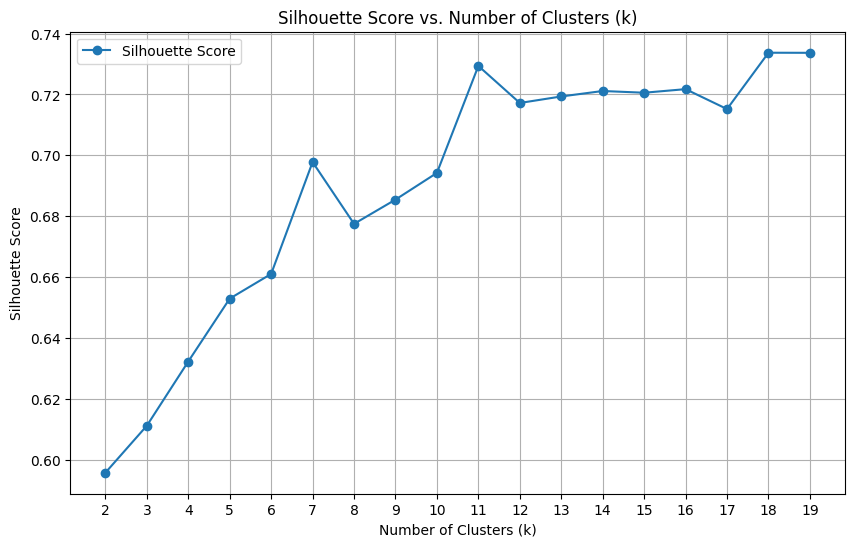

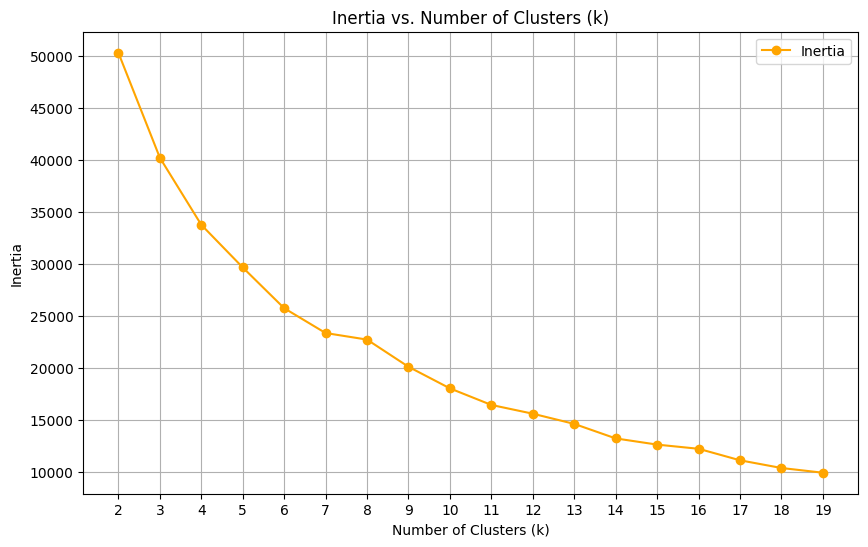

In [30]:
################################################################################
# PLOT SILHOUETTE SCORES
################################################################################

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', label='Silhouette Score')
plt.xticks(k_range)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.legend()
plt.grid(True)
plt.show()

################################################################################
# PLOT INERTIAS
################################################################################

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', color='orange', label='Inertia')
plt.xticks(k_range)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Inertia vs. Number of Clusters (k)')
plt.legend()
plt.grid(True)
plt.show()


Visualizing clusters with the best k=7...


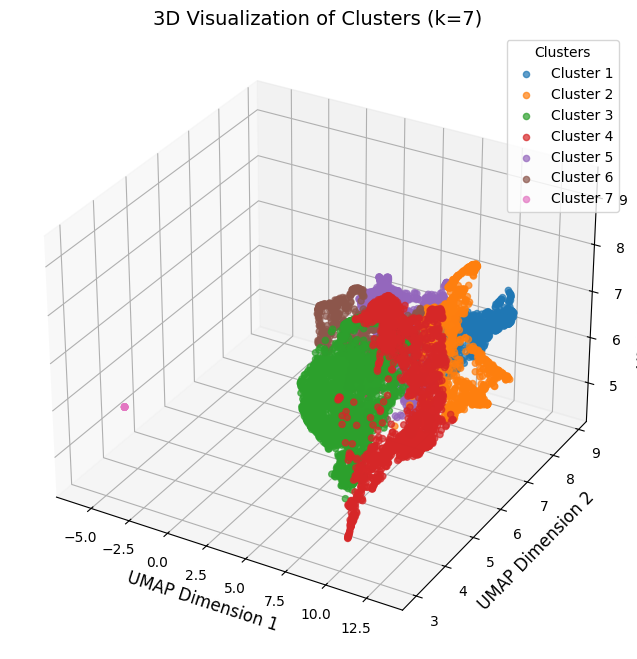

In [26]:
from matplotlib import cm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

################################################################################
# 3D Visualization of Clusters with the Best k
################################################################################

best_k = 7
print(f"Visualizing clusters with the best k={best_k}...")

final_kmeans = KMeans(n_clusters=best_k, init="k-means++", random_state=42)
train_labels = final_kmeans.fit_predict(train_umap_reduced)

colors = cm.tab10.colors if best_k <= 10 else cm.hsv(np.linspace(0, 1, best_k))

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

for cluster in range(best_k):
    cluster_points = train_umap_reduced[train_labels == cluster]
    ax.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        cluster_points[:, 2],
        label=f"Cluster {cluster + 1}",
        alpha=0.7,
        s=20,
        color=colors[cluster]
    )

ax.set_title(f"3D Visualization of Clusters (k={best_k})", fontsize=14)
ax.set_xlabel("UMAP Dimension 1", fontsize=12)
ax.set_ylabel("UMAP Dimension 2", fontsize=12)
ax.set_zlabel("UMAP Dimension 3", fontsize=12)
ax.legend(title="Clusters")
plt.show()


In [ ]:
################################################################################
# 7. DISPLAY CLUSTERED WORDS AND IDENTIFY OVERLAPPING WORDS
################################################################################

best_k = 7

print(f"\nBest k (excluding k=2 and k=3): {best_k}")
print("Clustering with the best k value...")


final_kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
train_labels = final_kmeans.fit_predict(train_umap_reduced)


clustered_words = {i: [] for i in range(best_k)}


for word_idx, cluster_idx in enumerate(train_labels):
    clustered_words[cluster_idx].append(train_vocab[word_idx])


word_to_clusters = {}
for cluster_idx, words in clustered_words.items():
    for word in words:
        if word not in word_to_clusters:
            word_to_clusters[word] = []
        word_to_clusters[word].append(cluster_idx)

overlapping_words = {word: clusters for word, clusters in word_to_clusters.items() if len(clusters) > 1}

for cluster_idx, words in clustered_words.items():
    print(f"\nCluster {cluster_idx}:")
    print(", ".join(words[:100]))
    print(f"... Total words in cluster: {len(words)}")

if overlapping_words:
    print("\nOverlapping Words Across Clusters:")
    for word, clusters in overlapping_words.items():
        print(f"{word}: Clusters {clusters}")
else:
    print("\nNo overlapping words found across clusters.")


In [ ]:
################################################################################
# 7. RETRAIN, THEN TEST AND ANALYSE ON UNSEEN DATA
################################################################################


trainval_tokens_combined = train_tokens_filtered

print("\nRebuilding co-occurrence matrix using Train+Val combined...")
final_vocab = normalize_frequencies(trainval_tokens_combined, min_freq=5)
trainval_co_matrix = build_normalized_co_occurrence(
    trainval_tokens_combined,
    final_vocab,
    window_size=5,
    min_freq=5
)

print("Building co-occurrence matrix for Test set (using final_vocab)...")
test_co_matrix = build_normalized_co_occurrence(
    test_tokens_filtered,
    final_vocab,
    window_size=5,
    min_freq=5
)

# Perform dimensionality reduction
print("\nPerforming PCA with 20 components...")
pca_final = PCA(n_components=20, random_state=42)
trainval_reduced_pca = pca_final.fit_transform(trainval_co_matrix)
test_reduced_pca = pca_final.transform(test_co_matrix)

print("\nApplying UMAP on top of PCA embeddings...")
umap_final = UMAP(
    n_components=5,
    n_neighbors=10,
    min_dist=0.1,
    random_state=42
)
trainval_reduced_umap = umap_final.fit_transform(trainval_reduced_pca)
test_reduced_umap = umap_final.transform(test_reduced_pca)

# Fit KMeans on Train+Val, evaluate on Test
best_k = 7
print(f"\nFitting KMeans with k={best_k}...")
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
trainval_labels = kmeans_final.fit_predict(trainval_reduced_umap)
test_labels = kmeans_final.predict(test_reduced_umap)

# Evaluate clustering on test data
if best_k > 1:
    test_sil_score = silhouette_score(test_reduced_umap, test_labels)
else:
    test_sil_score = -1

print(f"Test Silhouette Score with k={best_k}: {test_sil_score:.3f}")

# Analyze the distribution of clusters in the test set
from collections import Counter

cluster_counts = Counter(test_labels)
print("\nCluster Distribution in Test Set:")
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} samples")

# Optional: Calculate and print inertia for the test set
test_inertia = np.sum(np.min(
    np.linalg.norm(
        test_reduced_umap[:, np.newaxis] - kmeans_final.cluster_centers_, axis=2
    ), axis=1
))
print(f"Test Inertia: {test_inertia:.3f}")



Rebuilding co-occurrence matrix using Train+Val combined...
